In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import qutip
import numpy as np
import qutip
import scqubits
from scipy.optimize import minimize
from IPython.display import clear_output

from CoupledQuantumSystems.qobj_manip import *
from CoupledQuantumSystems.drive import *
from CoupledQuantumSystems.evo import ODEsolve_and_post_process
from CoupledQuantumSystems.noise import *
from CoupledQuantumSystems.qobj_manip import *
from CoupledQuantumSystems.IFQ import gfIFQ

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

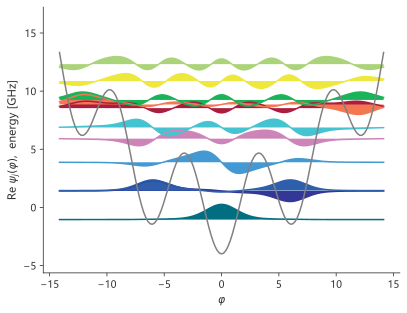

In [3]:
EJ = 4
EC = EJ/3
EL = EJ/30

qbt = gfIFQ(EJ = EJ,EC =EC,EL = EL,truncated_dim=13)

t_duration = 50
tlist = np.linspace(0,t_duration,t_duration)
e_ops = [qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(10)]
qbt.fluxonium.plot_wavefunction(which=[0,1,2,3,4,5,6,7,8,9,10])

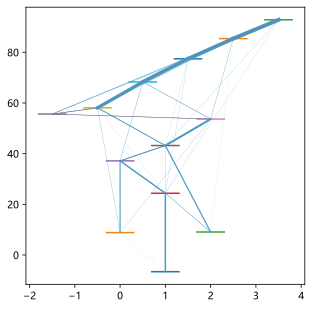

In [4]:
def visualize_c_ops(c_ops,evals):
    level_to_x = {
        0:1,
        1:0,
        2:2,
        3:1,
        4:0,
        5:1,
        6:2,
        7:-1.5,
        8:-0.5,
        9:0.5,
        10:1.5,
        11:2.5,
        12:3.5,
    }
    def plot_levels(ax):
        for ql,eval in enumerate(evals):
            eval_with_2pi = 2*np.pi*eval
            x = level_to_x[ql]
            length = 0.3
            ax.plot([x-length,x+length], [eval_with_2pi,eval_with_2pi])
    def plot_thermalization(ax):
        max_element = np.max(np.abs(np.square((c_ops.full()))))
        max_lw = 4
        lw_scaling_ratio = max_lw/max_element
        decay_color = '#4999c3'
        heating_color = '#d5373d'
        for i in range(len(evals)):
            for j in range(len(evals)):
                if i == j:
                    continue
                else:
                    i_y = 2*np.pi*evals[i]
                    j_y = 2*np.pi*evals[j]
                    i_x = level_to_x[i]
                    j_x = level_to_x[j]
                    ax.plot([i_x,j_x], [i_y,j_y], color = decay_color if i < j else heating_color, lw =lw_scaling_ratio* np.abs(np.square((c_ops[i,j])))  )
    fig, ax = plt.subplots(1,1,figsize = (5,5))
    plot_levels(ax)
    plot_thermalization(ax)
    return fig
temp_in_mK = 20
loss_tangent_ref = 5e-6
one_over_f_flux_noise_amplitude = 1e-6
c_ops=qbt.get_T1_c_ops(temp_in_mK,
                        loss_tangent_ref,
                        one_over_f_flux_noise_amplitude)
evals = qbt.fluxonium.eigenvals(evals_count=qbt.truncated_dim)

fig  = visualize_c_ops(c_ops,evals)

[2.8352579  2.83236774 0.0936445  0.09987682]


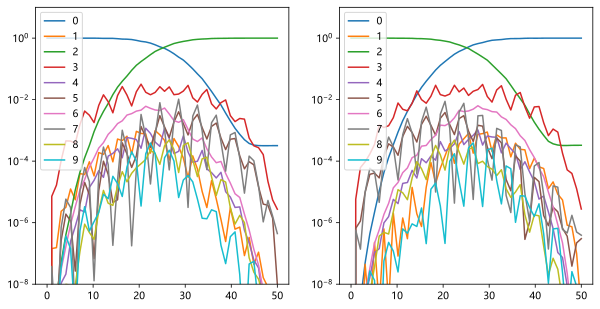

(0.014349908197431621, 0.012604715664849586, 0.00032400222917117194, 0.00033288322200031306)
 Total run time:   0.31s*] Elapsed 0.31s / Remaining 00:00:00:00 [*********56%*          ] Elapsed 0.17s / Remaining 00:00:00:00
 Total run time:   0.31s*] Elapsed 0.31s / Remaining 00:00:00:00


KeyboardInterrupt: 

In [7]:
def objective(x):
    # amp1_scaling_factor = 2.1866024
    # amp2_scaling_factor = 2.14973954
    # amp1_correction_scaling_factor = x[0]
    # amp2_correction_scaling_factor = x[1]
    # detuning1 =x[2]
    # detuning2 =x[3]

    amp1_scaling_factor = x[0]
    amp2_scaling_factor = x[1]
    amp1_correction_scaling_factor = x[2]
    amp2_correction_scaling_factor = x[3]
    detuning1 =0.5
    detuning2 =0.5

    results  = qbt.run_qutip_mesolve_parrallel(
        initial_states = [qutip.basis(qbt.truncated_dim, 0),qutip.basis(qbt.truncated_dim, 2)],
        tlist = tlist,
        drive_terms = qbt.get_Raman_DRAG_drive_terms(
            i = 0,
            j = 3,
            k = 2,
            detuning1=detuning1,
            detuning2 = detuning2,
            t_duration=t_duration,
            shape='sin^2',
            amp_scaling_factor = 1,
            amp1_scaling_factor = amp1_scaling_factor,
            amp2_scaling_factor = amp2_scaling_factor,
            amp1_correction_scaling_factor = amp1_correction_scaling_factor,
            amp2_correction_scaling_factor = amp2_correction_scaling_factor,
        ),
        # c_ops = c_ops,
        e_ops = e_ops
    )
    clear_output()
    print(x)
    fig, axes = plt.subplots(1,2,figsize = (10,5))
    for i, exp in enumerate(results[0].expect):
        axes[0].plot(tlist,exp,label= f"{i}")
    for i, exp in enumerate(results[1].expect):
        axes[1].plot(tlist,exp,label= f"{i}")
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].set_ylim(1e-8,1e1)
    axes[1].legend()
    axes[1].set_yscale('log')
    axes[1].set_ylim(1e-8,1e1)
    plt.show()
    
    result0_pop_57 = np.max(np.abs(results[0].expect[5] + results[0].expect[7]))
    result1_pop_57 = np.max(np.abs(results[1].expect[5] + results[1].expect[7]))

    one_minus_pop2 = np.abs( 1- (results[0].expect[2][-1]))
    one_minus_pop0 = np.abs(1- (results[1].expect[0][-1]))

    print((result0_pop_57, result1_pop_57, one_minus_pop2, one_minus_pop0))
    return 0.5* (result0_pop_57 + result1_pop_57) + one_minus_pop2 + one_minus_pop0

initial_guess =[2.7,2.7 ,0.1,0.1]


result = minimize(objective, initial_guess, method='Nelder-Mead')
